Mounted at /content/drive

🌊 SURVIVALVR-BD KNOWLEDGE GRAPH BUILDER

[1] ✅ Added 10 nodes to Knowledge Graph
[2] ✅ Added 5 edges to Knowledge Graph

📊 KNOWLEDGE GRAPH SUMMARY

📌 Nodes by Category:
   - food_sourcing: 1 nodes
   - navigation: 2 nodes
   - fishing: 1 nodes
   - survival: 2 nodes
   - fire: 1 nodes
   - weather: 1 nodes
   - emergency: 1 nodes
   - mental: 1 nodes

📌 Total Nodes: 10
📌 Total Edges: 5

📌 Node Details:
   - S1: Underwater Fishing (food_sourcing)
   - S1a: Current Direction Reading (navigation)
   - S1b: Fish Spotting (fishing)
   - S2: Fire Making (survival)
   - S2a: Fish Oil Fire (fire)
   - S3: Sea Reading (navigation)
   - S3a: Wave Pattern Recognition (weather)
   - S4: Safe Positioning (survival)
   - S4a: Cyclone Shelter (emergency)
   - S5: Psychological Preparation (mental)

📌 Edge Connections:
   - S1 --[connected_to]--> S1a
   - S1 --[connected_to]--> S1b
   - S2 --[connected_to]--> S2a
   - S3 --[connected_to]--> S3a
   - S4 --[connected_to]--> S4

/tmp/ipykernel_1510/809386158.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1510/809386158.py:150: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig(full_path, dpi=300, bbox_inches='tight')


[4] ✅ Graph saved to Google Drive: /content/drive/MyDrive/SurvivalVR_KnowledgeGraph.png


/tmp/ipykernel_1510/809386158.py:154: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/knowledge_graph.png", dpi=300, bbox_inches='tight')


[5] ✅ Graph saved locally: /content/knowledge_graph.png


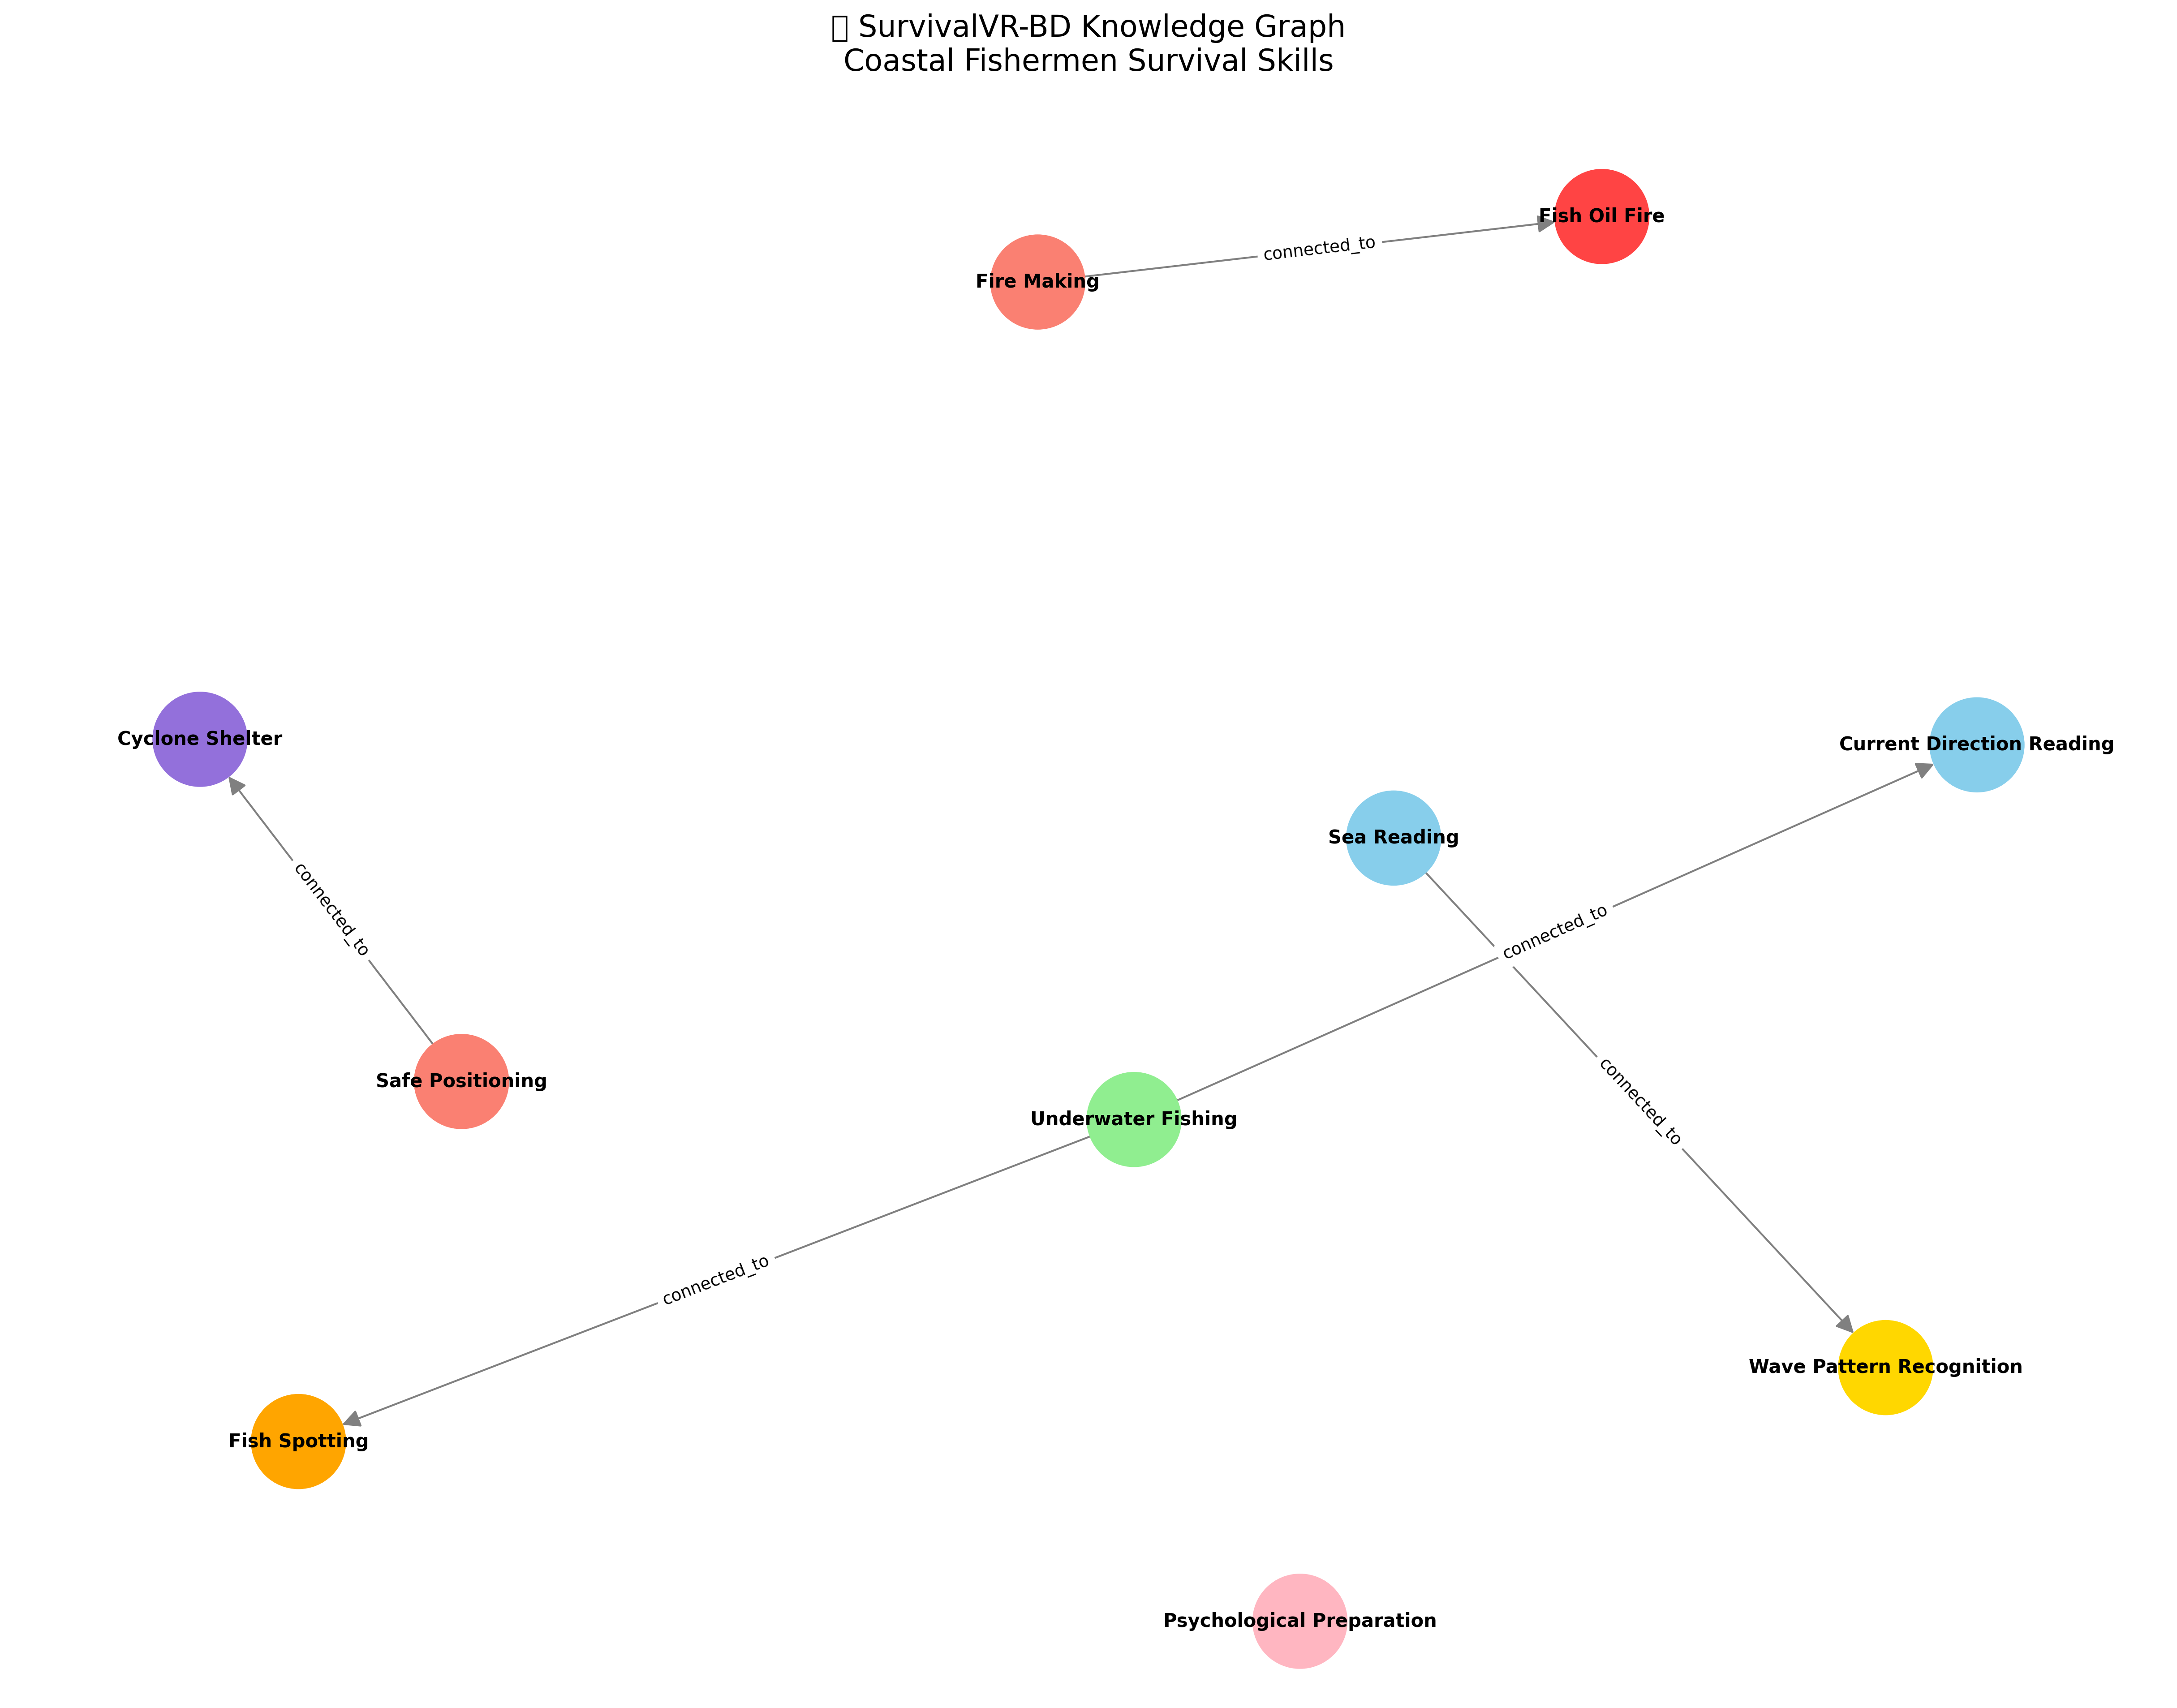

[6] ✅ Graph displayed in notebook

✅ ALL TASKS COMPLETED SUCCESSFULLY!
📁 Files saved in: /content/drive/MyDrive/
   - SurvivalVR_KnowledgeGraph.png (High-res graph)
   - knowledge_graph.json (Full data)


In [3]:
# =====================================================
# STEP 1: Mount Google Drive
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

# =====================================================
# STEP 2: Install Required Libraries (if not installed)
# =====================================================
!pip install networkx matplotlib -q

# =====================================================
# STEP 3: Import Libraries
# =====================================================
import json
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import Image, display
import os

# =====================================================
# STEP 4: Define the Knowledge Graph Class
# =====================================================
class SurvivalKnowledgeGraph:
    def __init__(self):
        """Knowledge Graph initialisation"""
        self.graph = nx.DiGraph()
        self._initialize_nodes()
        self._initialize_edges()

    def _initialize_nodes(self):
        """Initialize all nodes in the Knowledge Graph"""
        nodes = [
            {"id": "S1", "name": "Underwater Fishing", "category": "food_sourcing"},
            {"id": "S1a", "name": "Current Direction Reading", "category": "navigation"},
            {"id": "S1b", "name": "Fish Spotting", "category": "fishing"},
            {"id": "S2", "name": "Fire Making", "category": "survival"},
            {"id": "S2a", "name": "Fish Oil Fire", "category": "fire"},
            {"id": "S3", "name": "Sea Reading", "category": "navigation"},
            {"id": "S3a", "name": "Wave Pattern Recognition", "category": "weather"},
            {"id": "S4", "name": "Safe Positioning", "category": "survival"},
            {"id": "S4a", "name": "Cyclone Shelter", "category": "emergency"},
            {"id": "S5", "name": "Psychological Preparation", "category": "mental"}
        ]

        for node in nodes:
            self.graph.add_node(node["id"],
                               name=node["name"],
                               category=node["category"])
        print(f"[1] ✅ Added {len(nodes)} nodes to Knowledge Graph")

    def _initialize_edges(self):
        """Initialize edges between nodes"""
        edges = [
            ("S1", "S1a"), ("S1", "S1b"),
            ("S2", "S2a"),
            ("S3", "S3a"),
            ("S4", "S4a")
        ]
        for u, v in edges:
            self.graph.add_edge(u, v, relation="connected_to")
        print(f"[2] ✅ Added {len(edges)} edges to Knowledge Graph")

    def export_to_json(self, filename="knowledge_graph.json"):
        """Export Knowledge Graph to JSON format"""
        data = {
            "nodes": [
                {"id": n, **self.graph.nodes[n]}
                for n in self.graph.nodes
            ],
            "edges": [
                {"from": u, "to": v, "relation": d.get("relation", "connected")}
                for u, v, d in self.graph.edges(data=True)
            ]
        }
        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        print(f"[3] ✅ Knowledge Graph exported to {filename}")
        print(f"    - Total nodes: {len(data['nodes'])}")
        print(f"    - Total edges: {len(data['edges'])}")
        return data

    def display_summary(self):
        """Display a summary of the Knowledge Graph in console"""
        print("\n" + "="*60)
        print("📊 KNOWLEDGE GRAPH SUMMARY")
        print("="*60)

        categories = {}
        for node in self.graph.nodes(data=True):
            cat = node[1].get('category', 'unknown')
            categories[cat] = categories.get(cat, 0) + 1

        print("\n📌 Nodes by Category:")
        for cat, count in categories.items():
            print(f"   - {cat}: {count} nodes")

        print(f"\n📌 Total Nodes: {self.graph.number_of_nodes()}")
        print(f"📌 Total Edges: {self.graph.number_of_edges()}")

        print("\n📌 Node Details:")
        for node in self.graph.nodes(data=True):
            print(f"   - {node[0]}: {node[1].get('name')} ({node[1].get('category')})")

        print("\n📌 Edge Connections:")
        for u, v, data in self.graph.edges(data=True):
            print(f"   - {u} --[{data.get('relation')}]--> {v}")
        print("="*60)

    def save_to_drive(self, filename="knowledge_graph.png", drive_path="/content/drive/MyDrive/"):
        """Save the graph visualization to Google Drive"""
        plt.figure(figsize=(16, 12))
        pos = nx.spring_layout(self.graph, k=0.8, seed=42)

        # Color mapping
        color_map = {
            'food_sourcing': '#90EE90',
            'navigation': '#87CEEB',
            'fishing': '#FFA500',
            'survival': '#FA8072',
            'fire': '#FF4444',
            'weather': '#FFD700',
            'emergency': '#9370DB',
            'mental': '#FFB6C1'
        }

        node_colors = []
        for node in self.graph.nodes:
            category = self.graph.nodes[node].get('category', 'unknown')
            node_colors.append(color_map.get(category, '#CCCCCC'))

        # Draw
        nx.draw(self.graph, pos, with_labels=False,
                node_color=node_colors, edge_color='gray',
                node_size=2500, arrows=True, arrowsize=20)

        # Labels
        labels = {n: self.graph.nodes[n].get('name', n) for n in self.graph.nodes}
        nx.draw_networkx_labels(self.graph, pos, labels, font_size=10, font_weight='bold')

        # Edge labels
        edge_labels = {(u, v): d.get('relation', '') for u, v, d in self.graph.edges(data=True)}
        nx.draw_networkx_edge_labels(self.graph, pos, edge_labels, font_size=9)

        plt.title("🌊 SurvivalVR-BD Knowledge Graph\nCoastal Fishermen Survival Skills", fontsize=16)
        plt.tight_layout()

        # Save to Drive
        full_path = os.path.join(drive_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"[4] ✅ Graph saved to Google Drive: {full_path}")

        # Also save to local Colab
        plt.savefig("/content/knowledge_graph.png", dpi=300, bbox_inches='tight')
        print(f"[5] ✅ Graph saved locally: /content/knowledge_graph.png")

        plt.close()
        return full_path

    def show_in_notebook(self):
        """Display the graph in the Jupyter notebook"""
        try:
            from IPython.display import Image, display
            display(Image(filename="/content/knowledge_graph.png"))
            print("[6] ✅ Graph displayed in notebook")
        except:
            print("[6] ⚠️ Could not display image in notebook. Check if file exists.")


# =====================================================
# STEP 5: RUN THE CODE
# =====================================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print("🌊 SURVIVALVR-BD KNOWLEDGE GRAPH BUILDER")
    print("="*60 + "\n")

    # Create Knowledge Graph
    kg = SurvivalKnowledgeGraph()

    # Display summary
    kg.display_summary()

    # Export to JSON (saves in Colab local)
    json_data = kg.export_to_json("knowledge_graph.json")

    # Copy JSON to Drive
    !cp knowledge_graph.json /content/drive/MyDrive/
    print("[4] ✅ JSON file copied to Google Drive")

    # Save graph to Drive
    kg.save_to_drive("SurvivalVR_KnowledgeGraph.png")

    # Display in notebook
    kg.show_in_notebook()

    print("\n" + "="*60)
    print("✅ ALL TASKS COMPLETED SUCCESSFULLY!")
    print("📁 Files saved in: /content/drive/MyDrive/")
    print("   - SurvivalVR_KnowledgeGraph.png (High-res graph)")
    print("   - knowledge_graph.json (Full data)")
    print("="*60)